In [1]:
!pip install -r ../requirements.txt

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb

Napomena - pri višestrukom ponavljanju ove analize zaklučio sam da je dataset pun duplikata, jedan od razloga za to je zato što je ovaj dataset prikupljen korišćenjem honeypot mejlova. Ovo je imalo za posledicu da moji modeli imaju preciznost od 99%, tako da sam odlučio da odbacim što više duplikata tako da bi model bio generalizovan i treniran na heterogenim terminima u mejlovima.

In [3]:
data = pd.read_csv('../data/emails/CEAS_08.csv')
# data = data.sample(n=1000,random_state=42)
data = data.drop_duplicates(subset=['subject'], keep='first')
data = data.drop_duplicates(subset=['body'], keep='first')
data = data.drop_duplicates(subset=['sender','receiver'],keep='first')
data

,sender,receiver,date,subject,body,label,urls
0,Young Esposito <Young@iworld.de>,user4@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 16:31:02 -0700",Never agree to be a loser,"Buck up, your troubles caused by small dimensi...",1,1
1,Mok <ipline's1983@icable.ph>,user2.2@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 18:31:03 -0500",Befriend Jenna Jameson,\nUpgrade your sex and pleasures with these te...,1,1
2,Daily Top 10 <Karmandeep-opengevl@universalnet...,user2.9@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 20:28:00 -1200",CNN.com Daily Top 10,>+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+...,1,1
3,Michael Parker <ivqrnai@pobox.com>,SpamAssassin Dev <xrh@spamassassin.apache.org>,"Tue, 05 Aug 2008 17:31:20 -0600",Re: svn commit: r619753 - in /spamassassin/tru...,Would anyone object to removing .so from this ...,0,1
4,Gretchen Suggs <externalsep1@loanofficertool.com>,user2.2@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 19:31:21 -0400",SpecialPricesPharmMoreinfo,\nWelcomeFastShippingCustomerSupport\nhttp://7...,1,1
...,...,...,...,...,...,...,...
39136,bradly weidong <administrator@aba-uk.org>,cstheory@gvc.ceas-challenge.cc,"Fri, 08 Aug 2008 12:11:35 +0000",Finally your new healthy life. 85,\n Find your love stick gain he...,1,0
39138,robert healy <vrcjauctt@gmail.com>,pvosgpr@triptracker.net,"Fri, 08 Aug 2008 05:59:51 -0800",I want to cancel my account,How do I cancel my account. I want to erase i...,0,0
39139,freddie <freddie_jeffries@branch3es.info>,user2.1-ext1@gvc.ceas-challenge.cc,"Fri, 08 Aug 2008 13:59:53 +0000",some contact information for you,This message is intended for :\n\n*SAVE! SAVE...,1,1
39143,Wendy Richter <gerich@miffbank.com>,brenda.semien@gvc.ceas-challenge.cc,"Fri, 08 Aug 2008 15:00:15 +0100",Woman 38 Richter,+++++++++++++++++++++++++++++++++++\nLana\nI a...,1,1


U datom datasetu postoje sledece promenljive:
Sender - Naziv posiljaoca  i mejl adresa
Receiver - mejl adresa primaoca
Date - datum slanja
Subject - naslov mejla
Body - sadrzaj mejla
Label - binarna promenljiva koja oznacava da li mejl predstavlja phishing napad ili ne. 1 je phishing dok 0 nije.
Urls - binarna promenljiva koja oznacava da li se u mejlu nalaze url-ovi

In [4]:
data.info()

<class 'pandas.DataFrame'>
Index: 11185 entries, 0 to 39151
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   sender    11185 non-null  str  
 1   receiver  11102 non-null  str  
 2   date      11185 non-null  str  
 3   subject   11184 non-null  str  
 4   body      11185 non-null  str  
 5   label     11185 non-null  int64
 6   urls      11185 non-null  int64
dtypes: int64(2), str(5)
memory usage: 699.1 KB


In [5]:
data.receiver.value_counts()

receiver
user6@gvc.ceas-challenge.cc                                               397
user2.2@gvc.ceas-challenge.cc                                             395
user2.4@gvc.ceas-challenge.cc                                             299
user7-ext4@gvc.ceas-challenge.cc                                          292
user2.13@gvc.ceas-challenge.cc                                            291
                                                                         ... 
Christian Campbell <yekxpbaab@brueggers.com>                                1
Rich Neo <bf-jgyyrpxggb@neiu.edu>                                           1
Dave Koontz <fcquqwd@mbc.edu>                                               1
"Maier,Chris" <dmeuc.tpvnl@heb.com>                                         1
rgkwpdahmhmail@cs.cmu.edu, faq@engr.orst.edu, ji-ivay@googlegroups.com      1
Name: count, Length: 1954, dtype: int64

Kao sto se moze videti, veliki broj mejlova ima iste primaoce, pretpostavljam da su ovi mejlovi sluzili kao honeypot-ovi za prikupljanje phishing napada. Podaci primaoca se onda tesko mogu koristiti za klasifikaciju.

Postoji rizik od overfitting-a, ukoliko treniram model na ovim podacima. Jedino za sta bi mogla da mi sluzi promenljiva primaoc je da se na primer poredi adresa primaoca i posiljaoca. Ukoliko su mejl serveri isti, onda postoji veca sansa da je mejl validan

Probacu da nadjem mejlove(opservacije) koje sadrze isti mejl servera posiljaoca i primaoca

In [6]:
sender_domain = data['sender'].str.split("@").str[1].str.removesuffix(">")
receiver_domain = data['receiver'].str.split("@").str[1].str.removesuffix(">")

internal_sending_data = data.loc[sender_domain == receiver_domain]
internal_sending_data.head(10)

,sender,receiver,date,subject,body,label,urls
22,ohwwlejs-pbfotbp@list.scms.waikato.ac.nz,iuxxdkqk@list.scms.waikato.ac.nz,"Tue, 05 Aug 2008 18:32:19 -0500","Wekalist Digest, Vol 60, Issue 10",Send Wekalist mailing list submissions to\n\ti...,0,1
54,Perl Jobs <xycn-vtnhz@perl.org>,necc@perl.org,"Tue, 05 Aug 2008 02:47:22 -0800","[Perl Jobs] Perl developer, Hungary, Budapest",Online URL for this job: http://jobs.perl.org/...,0,1
88,"""Mickisch, Freda"" <e.bsnrgtrf@massey.ac.nz>",yrvc-tke@massey.ac.nz,"Wed, 06 Aug 2008 12:34:55 +1300",Supervisors PhD students: 6-monthly reports...,Hi \n\n \n\nJust a reminder that these are due...,0,0
102,user2.13@gvc.ceas-challenge.cc,user2.13@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 14:36:16 -0400",Angelina Jolie Free Video.,\n\n\n\n\n\n\n\n\n\n\n\nFree Video Nude Anjeli...,1,0
123,demerphq <oryiufjn@gmail.com>,Rafael Garcia-Suarez <pvhuhqgncrxnu@gmail.com>,"Wed, 06 Aug 2008 01:36:57 +0200",Re: Regex issue with scoping in loops.,"On 10/3/07, Rafael Garcia-Suarez wrote:\n> On...",0,1
125,"""Mickisch, Freda"" <e.bsnrgtrf@massey.ac.nz>",iwrj-eda@massey.ac.nz,"Wed, 06 Aug 2008 12:31:49 +1300",PhD 6 monthly reports...thanks...,"Hi All \n\n \n\nThanks to PhDs, Supervisors an...",0,0
144,"""alt.spam group"" <uiaregi@googlegroups.com>","""alt.spam abridged email subscribers"" <cks.uap...","Tue, 05 Aug 2008 23:38:09 +0000",5 new messages in 4 topics - abridged,\nalt.spam\nhttp://groups.google.com/group/al...,0,1
145,"""news.admin.net-abuse.email group"" <uiaregi@go...","""news.admin.net-abuse.email abridged email sub...","Tue, 05 Aug 2008 23:38:04 +0000",29 new messages in 14 topics - abridged,news.admin.net-abuse.email http://groups.googl...,0,1
152,"""SourceForge.net"" <uiaregi@sourceforge.net>",uiaregi@sourceforge.net,"Tue, 05 Aug 2008 16:39:23 -0700",[ spambayes-Patches-1707814 ] More resilient p...,"Patches item #1707814, was opened at 2007-04-2...",0,1
191,upxujwlbmsdyft@yahoogroups.com,upxujwlbmsdyft@yahoogroups.com,"Tue, 05 Aug 2008 23:38:56 +0000",[duodenalswitch] Digest Number 13712,Duodenal Switch obesity surgery support ...,0,1


In [7]:
internal_sent = internal_sending_data.loc[internal_sending_data['label'] == 0]
print(f"Ukupan broj internih mejlova koji nisu phising: {len(internal_sent)} od {len(internal_sending_data)}")

Ukupan broj internih mejlova koji nisu phising: 276 od 295


In [8]:
data['is_internal'] = sender_domain == receiver_domain
data['is_internal'] = data['is_internal'].map({True:1,False: 0})

Kao sto se moze videti veliki broj izdvojenih mejlova su zaista rezultat internog slanja. Predstavljaju oko 3% internog slanja, nije veliki broj ovakvih opservacija ali predstavljaju bitan podatak za povecanje sigurnosti bezbednog mejla. Moguce je izvrsiti transformaciju gde ce se dodati binarna promenljiva is_internal. Zakljucujem da postoji velika korelacija izmedju poklapanja serverskih domena i status spam-a

Sledece sto se moze proveriti je da li kako izgledaju opservacije koje nemaju specificiranog primaoca, ovakvi mejlovi obicno predstavljaju spam ako su mejlovi samo navedeni u bcc

In [9]:
no_recipient_mails = data.loc[data['receiver'].isna() == True]
no_recipient_mails

,sender,receiver,date,subject,body,label,urls,is_internal
620,mouss <qpeqr@netoyen.net>,NaN,"Wed, 06 Aug 2008 01:05:33 +0100",Re: SASL questions,"AlxFrag wrote:\n> Hi,\n>\n> i have a couple of...",0,0,0
2043,jdd <xyi@dodin.org>,NaN,"Wed, 06 Aug 2008 02:29:48 +0100",Re: [opensuse] Re: openSUSE Boxed Editions,Aaron Kulkis a écrit :\n\n> so that the primar...,0,1,0
4354,u.dgfphz@massey.ac.nz,NaN,"Wed, 06 Aug 2008 16:55:08 +1300",Professorial Lecture - 6th March,Hi Everyone\n\nI would like to remind you of t...,0,1,0
4548,Gabriel Genellina <ynuffj-wvo@phaseit.net>,NaN,"Tue, 05 Aug 2008 05:27:12 +0000",Python-URL! - weekly Python news and links (Fe...,"QOTW: ""I think not enough is made of the fact...",0,1,0
4557,Tim Golden <cggc@timgolden.me.uk>,NaN,"Wed, 06 Aug 2008 04:22:28 +0000",Re: [python-win32] Launching a New Instance of...,Jon Peck wrote:\n> We need to launch Excel fro...,0,1,0
...,...,...,...,...,...,...,...,...
33406,Jan Peters <cggc@jan-peters.net>,NaN,"Fri, 08 Aug 2008 06:18:56 +0200",[UAI] NIPS 2007 WORKSHOP: Robotics Challenges ...,*** Apologies for Multipl...,0,1,0
34498,jdd <xyi@opensuse.org>,NaN,"Fri, 08 Aug 2008 07:53:06 +0100",Re: [opensuse] [OT] unstable system - still t...,Per Jessen a écrit :\n\n> So now what?\n\nI've...,0,1,0
34874,Gryffus <ddxhffe@hkfree.org>,NaN,"Fri, 08 Aug 2008 08:39:18 +0100",Re: [opensuse] Kernel version questions,Or you can trust to community. Just fire-up ya...,0,1,0
34898,Agnello George <nydnuik.hhtbfx@gmail.com>,NaN,"Fri, 08 Aug 2008 13:11:16 +0530",Re: logrotate query !,"On 3/4/08, Martin Gregorie wrote:\n>\n> On Mo...",0,0,0


In [10]:
no_recipient_mails_ham = no_recipient_mails.loc[no_recipient_mails['label'] == 0]
print(f"Ukupan broj mejlova bez primaoca koji nisu spam: {len(no_recipient_mails_ham)} od {len(no_recipient_mails)}")

Ukupan broj mejlova bez primaoca koji nisu spam: 81 od 83


Moja pocetna tvrdnja ipak nije bila tacna, tako da cu odstraniti opservacije koje nemaju vrednost primaoca

In [11]:
data.dropna(axis=0,subset=['receiver'],inplace=True)

Sledeca promenljiva koju posmatram je date promenljiva. Treniranjem modela nad ovom promenljivom, predstavlja veliki rizik za overfitting modela i datumi su iz 2008 godine. Jedino kako mislim da bi se ova promenljiva mogla koristiti je tako da se izdvoje dani u nedelji i na nauci model u kada su napadi najcesci. Zasad to necu raditi. Proveriti sa profesorkom

Posto treniranjem modela na celokupnim datumima nece biti korisno, iz datuma cu izdvojiti dane u nedelji kao i vreme kad su se slali mejlovi pa cu utvrditi da li oni doprinose razdvajanju klasa. Pre izdvajanja, potrebno je da konvertujem object promenljivu u datetime promenljivu

In [12]:
data['date'] = pd.to_datetime(data['date'], format="%a, %d %b %Y %H:%M:%S %z",utc=True, errors='coerce')

In [13]:
data.info()

<class 'pandas.DataFrame'>
Index: 11102 entries, 0 to 39151
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype              
---  ------       --------------  -----              
 0   sender       11102 non-null  str                
 1   receiver     11102 non-null  str                
 2   date         11090 non-null  datetime64[us, UTC]
 3   subject      11101 non-null  str                
 4   body         11102 non-null  str                
 5   label        11102 non-null  int64              
 6   urls         11102 non-null  int64              
 7   is_internal  11102 non-null  int64              
dtypes: datetime64[us, UTC](1), int64(3), str(4)
memory usage: 780.6 KB


Isto cu uraditi i za casove u toku dana

In [14]:
data['day_of_week'] = data['date'].dt.strftime("%a")

In [15]:
data['day_of_week'] = data['day_of_week'].map({'Sun':0,'Mon':1,'Tue':2,'Wed':3,'Thu':4,'Fri':5,'Sat': 5})

In [16]:
data['hour_of_day'] = data['date'].dt.strftime("%H")

Posto sam izveo promenljive iz datetime-a za analizu, odbacicu originalnu promenljivu datetime

In [17]:
data.drop(columns=['date'],inplace=True)

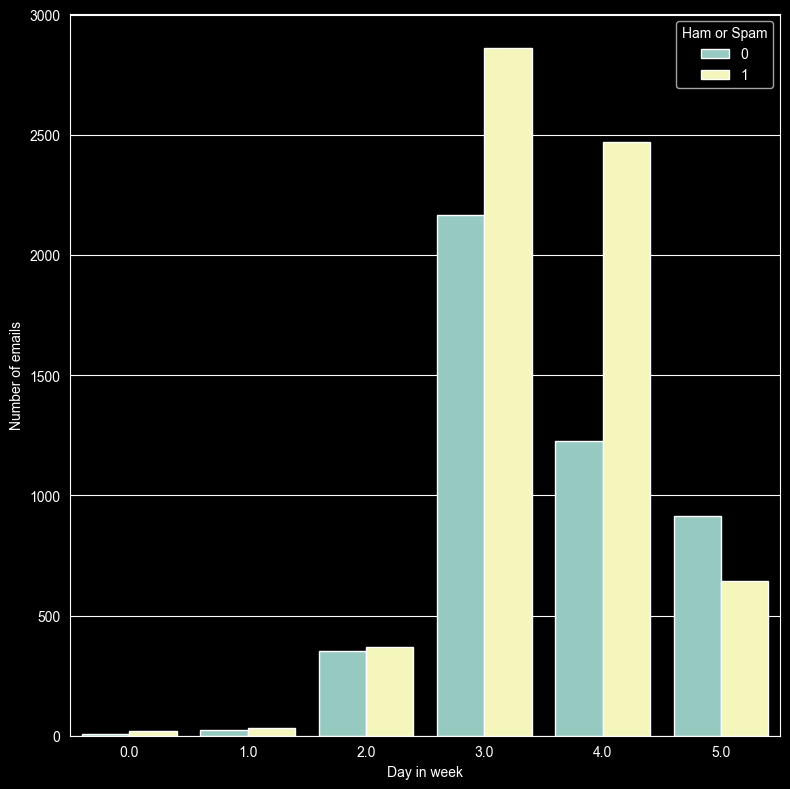

In [18]:
plt.figure(figsize=(8,8))
sb.countplot(data=data,x='day_of_week',hue='label')
plt.xlabel('Day in week')
plt.ylabel('Number of emails')
plt.legend(title='Ham or Spam')
plt.tight_layout()
plt.show()

Nisam siguran na osnovu grafikona da procenim da li se raspodele razlikuju, pa cu primeniti Hi-kvadrat test da utvrdim koliko je jaka veza izmedju dva kategoricka obelezja

In [19]:
from scipy.stats import chi2_contingency
crosstab = pd.crosstab(data['day_of_week'],data['label'])
stat,p,dof,expected = chi2_contingency(crosstab)
print("Ho: Promenljive dan u nedelji i label su statisticki nezavisni")
print("H1: Promenljive dan u nedelji i label su statisticki zavisni")
print(f"P vrednost Hi-kvadrat testa je: {p}")

Ho: Promenljive dan u nedelji i label su statisticki nezavisni
H1: Promenljive dan u nedelji i label su statisticki zavisni
P vrednost Hi-kvadrat testa je: 9.481312932643401e-66


Dobijena p vrednost je manja od 0.05 tako da odbacujem nultu i prihvatam alternativnu hipotezu da postoji zavisnost izmedju ove dve promenljive. Zadrzacu ovu promenljivu


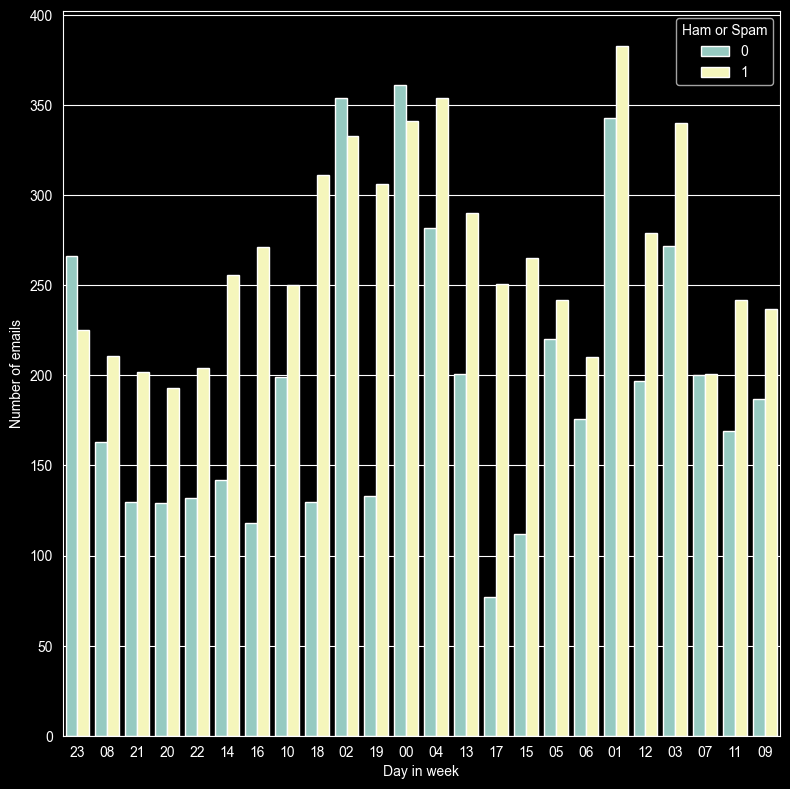

In [20]:
plt.figure(figsize=(8,8))
sb.countplot(data=data,x='hour_of_day',hue='label')
plt.xlabel('Day in week')
plt.ylabel('Number of emails')
plt.legend(title='Ham or Spam')
plt.tight_layout()
plt.show()

Sa grafikona vec mogu da vidim da se raspodele casova u odnosu na labelu raziliku. Ali za svaki slucaj cu primeniti Hi kvadrat test da ovo potvrdim


In [21]:
crosstab = pd.crosstab(data['hour_of_day'],data['label'])
stat,p,dof,expected = chi2_contingency(crosstab)
print("Ho: Promenljive dan u nedelji i label su statisticki nezavisni")
print("H1: Promenljive dan u nedelji i label su statisticki zavisni")
print(f"P vrednost Hi-kvadrat testa je: {p}")

Ho: Promenljive dan u nedelji i label su statisticki nezavisni
H1: Promenljive dan u nedelji i label su statisticki zavisni
P vrednost Hi-kvadrat testa je: 3.853855045534494e-43


Dobijena p vrednost je manja od 0.05 tako da odbacujem nultu i prihvatam alternativnu hipotezu da postoji zavisnost izmedju ove dve promenljive. Zadrzacu ovu promenljivu


Pre nastavka analize potrebno je da proverim kako raspodela promenljive urls u odnosu na vrednost label(phising ili ne) utice na razdvajanje klasa


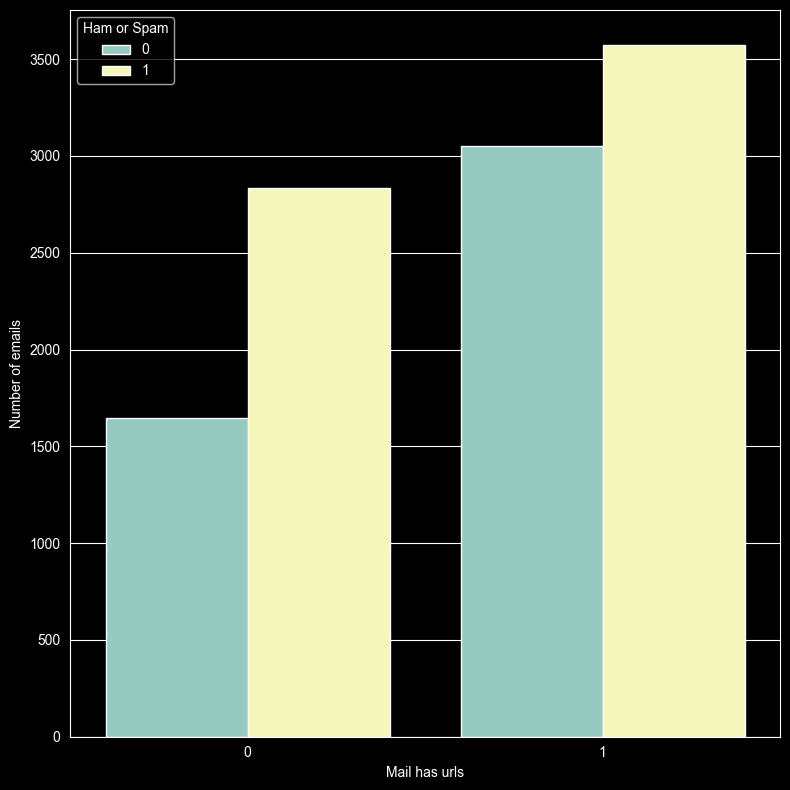

In [22]:
plt.figure(figsize=(8,8))
sb.countplot(data=data, x='urls',hue='label')
plt.xlabel('Mail has urls')
plt.ylabel('Number of emails')
plt.legend(title='Ham or Spam')
plt.tight_layout()
plt.show()

Na osnovu grafikona se moze zakljuciti da su raspodele promenljive urls u odnosu na promenljivu label iste, ovu promenljivu cu odstraniti iz prediktivnih promenljivi

Na osnovu deteljnog pregleda dataset-a može se primetiti veliki broj reply mejlova koji su u formatu Re: (odgovor). Takođe postoji veliki broj mejlova koji u naslovu sadrže neku vrstu zaglavlja tipa [Perl Jobs], ova obeležja zajedno sa forward formatom predstavljaju snažan indikator da ovi mejlovi nisu spam. Koristiću regex-e da izvučem ovo obeležje

In [23]:
import re

are_replies = data[data['subject'].str.match(r"^Re\s*",flags=re.IGNORECASE,na=False)]
ham_replies = are_replies.loc[are_replies['label'] == 0]
print(f"{len(ham_replies)} od {len(are_replies)} mejlova koji sadrze Re: (kao reply) zaista nisu spam mejlovi")

are_forwards = data[data['subject'].str.contains(r"Fwd\s*",flags=re.IGNORECASE,na = False)]
ham_are_forwards = are_forwards.loc[are_forwards['label']==0]
print(f"{len(ham_are_forwards)} od {len(are_forwards)} mejlova koji sadrze Re: (kao reply) zaista nisu spam mejlovi")

subject_metadata = data[data['subject'].str.contains(r"\[.*?\]",na=False)]
ham_subject_metadata = subject_metadata.loc[subject_metadata['label'] == 0]
print(f"{len(ham_subject_metadata)} od {len(subject_metadata)} mejlova koji sadrze meta podatke u formatu [*] zaista nisu spam mejlovi")

1439 od 1622 mejlova koji sadrze Re: (kao reply) zaista nisu spam mejlovi
55 od 55 mejlova koji sadrze Re: (kao reply) zaista nisu spam mejlovi
2845 od 2855 mejlova koji sadrze meta podatke u formatu [*] zaista nisu spam mejlovi


In [24]:
data['is_reply'] = data['subject'].str.match(r"^Re\s*",flags=re.IGNORECASE,na=False).astype(int)
data['has_subject_header'] = data['subject'].str.contains(r"\[.*?\]",na=False).astype(int)
data['is_forward'] = data['subject'].str.contains(r"Fwd\s*",flags=re.IGNORECASE,na=False).astype(int)

In [25]:
data[['subject','is_reply','has_subject_header','is_forward','label']].sample(10)

,subject,is_reply,has_subject_header,is_forward,label
22852,pharmacopoeia conic hallucinate trombone mulli...,0,0,0,1
2239,All Your Breast Enlargement Info From Top Brea...,0,0,0,1
13533,[UAI] call for demos,0,1,0,0
5706,Re: [ILUG] Broadband in Dublin,1,1,0,0
16541,Raw video of Paris k,0,0,0,1
14008,Re: [ILUG] ILUG AGM 2007...,1,1,0,0
37360,"""The Awfulness and Necessity of Cultural Studies""",0,0,0,0
27129,Try VPXL to enlarge your penis size and see th...,0,0,0,1
23158,From Warren Rouse,0,0,0,1
15617,Re: [opensuse] Novell client for Linux,1,1,0,0


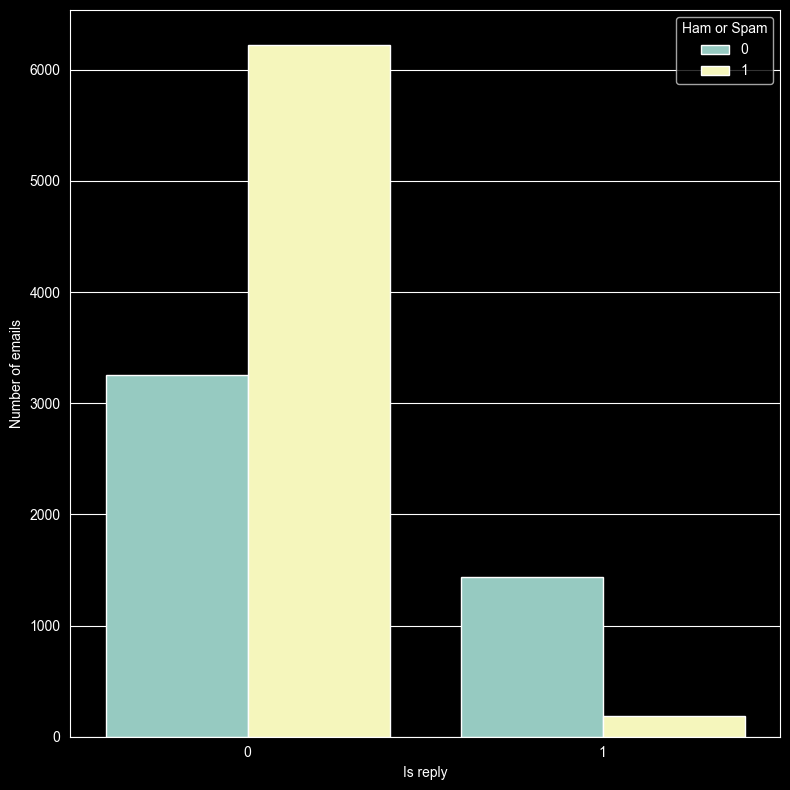

In [26]:
plt.figure(figsize=(8,8))
sb.countplot(data=data, x='is_reply',hue='label')
plt.xlabel('Is reply')
plt.ylabel('Number of emails')
plt.legend(title='Ham or Spam')
plt.tight_layout()
plt.show()

Raspodele promenljive is_reply u odnosu na vrednost labele se razlikuju, zbog toga može doprineti razdvajanju klasa. Zadržaću je u analizi


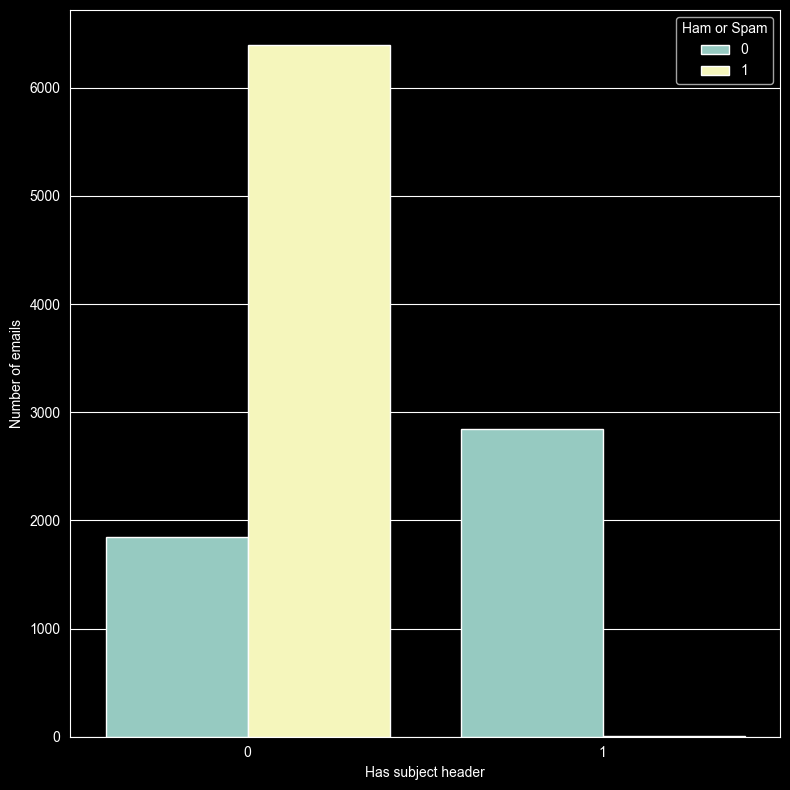

In [27]:
plt.figure(figsize=(8,8))
sb.countplot(data=data, x='has_subject_header',hue='label')
plt.xlabel('Has subject header')
plt.ylabel('Number of emails')
plt.legend(title='Ham or Spam')
plt.tight_layout()
plt.show()

Raspodela promenljive has_subject_header u odnosu na vrednosti zavisne promenljive se značajno razlikuju, promenljiva može doprineti razdvajanju klasa. Zadržaću je u analizi.

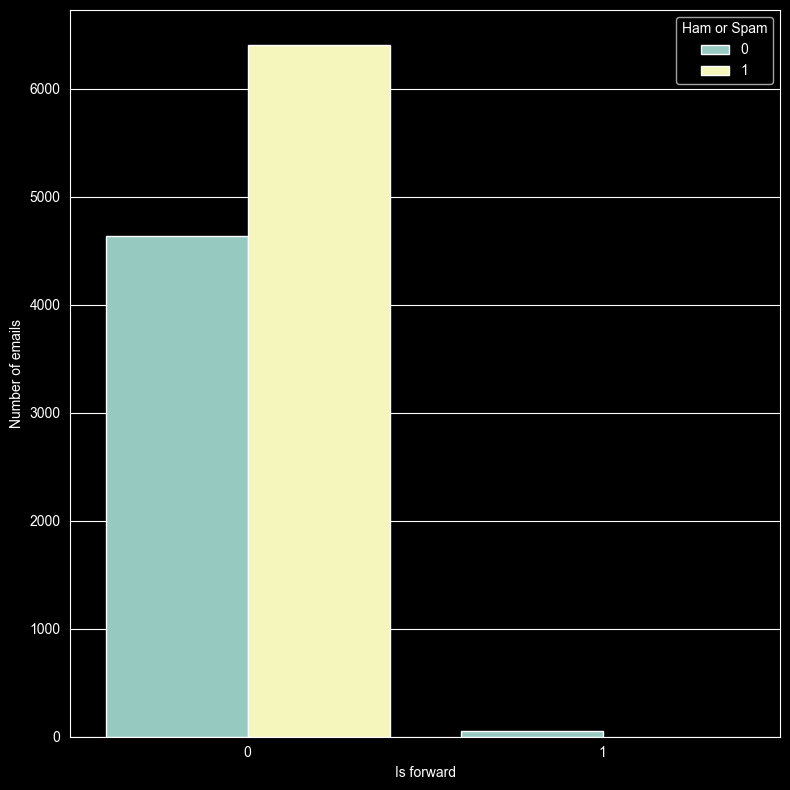

In [28]:
plt.figure(figsize=(8,8))
sb.countplot(data=data, x='is_forward',hue='label')
plt.xlabel('Is forward')
plt.ylabel('Number of emails')
plt.legend(title='Ham or Spam')
plt.tight_layout()
plt.show()

Raspodela promenljive is_forward u odnosu na vrednosti zavisne promenljive se značajno razlikuju, promenljiva može doprineti razdvajanju klasa. Zadržaću je u analizi.


Izdvajanje obeležja - Sender

Promenljiva sender ima sledeci oblik NazivPosiljaoca <emailadresa>. Naziv posiljaoca mi nije od velikog znacaja kao ni korisnicko ime, jedino sto ce mi omoguciti da utvrdim da li je spam mejl ili ne je domen mejl servera.

Sender - provericu da li mejl server u sebi sadrzi brojeve(npr. m1crosoft.com), jer to cesto moze predstavljati kljucan indikator spam mejlova. Opet sama adresa posiljaoca nece imati koristi za treniranje modela, ali moguce je izvesti promenljivu na primer has_number_in_sender_server.

In [29]:
def sender_to_email(sender):
    if sender and "<" in sender:
        email = sender.split("<")[1].removesuffix(">")
        return email
    else:
        return ""
data['sender'] = data['sender'].apply(sender_to_email)

In [30]:
def email_to_domain(email):
    if "@" in email:
        domain = email.split("@")[1]
        return domain
    else:
        return ""
data['sender'] = data['sender'].apply(email_to_domain)

Takođe veliki broj spam mejlova u svom domenu sadrži brojeve, klasičan primer pokušaja obmane su mejlovi koji zamenjuju karaktere brojevima, npr. m1crosoft.com

In [31]:
def domain_has_numbers(email):
    if "@" in email:
        email = email.split("@")[1].removesuffix(">")
        return any(char.isdigit() for char in email)
    return False
data['has_number_in_sender_server'] = data['sender'].apply(domain_has_numbers)

In [32]:
data.loc[(data['has_number_in_sender_server'] == True) & (data['label'] == 1)]

,sender,receiver,subject,body,label,urls,is_internal,day_of_week,hour_of_day,is_reply,has_subject_header,is_forward,has_number_in_sender_server


Ovaj dataset izgleda ne poseduje ni jedan mejl koji sadrži domen ovog tipa, promenljiva će ipak biti preskočena

In [33]:
data.drop(labels=['has_number_in_sender_server'],axis=1,inplace=True)

Takođe testiraće se broj poddomena imejl adrese, obično profesionalni mejlovi imaju kratke domene

In [34]:
def num_of_dots(domain):
    return domain.count('.')
data['email_dots'] = data['sender'].apply(num_of_dots)

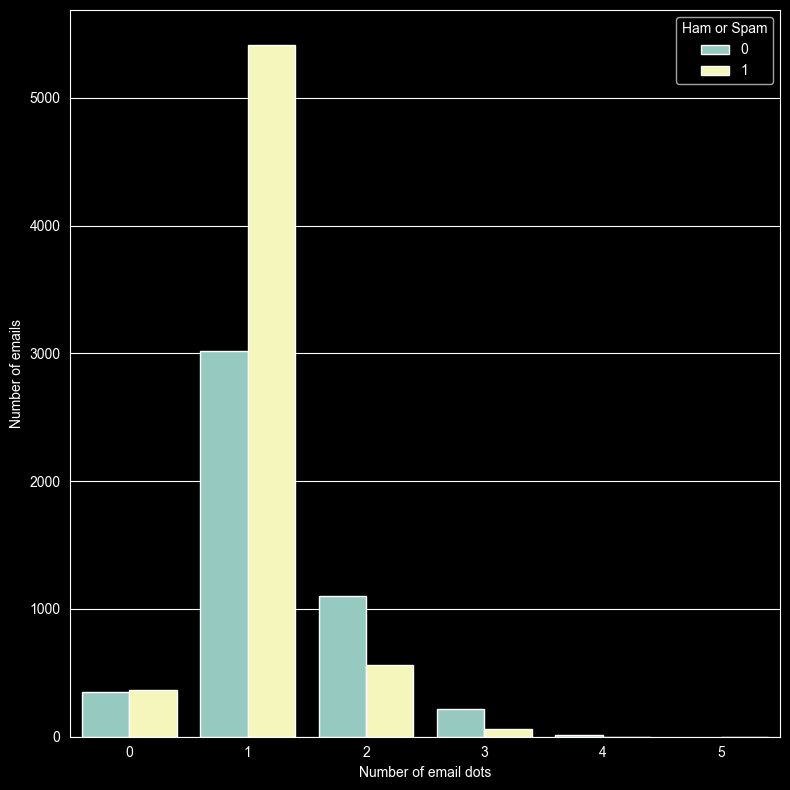

In [35]:
plt.figure(figsize=(8,8))
sb.countplot(data=data, x='email_dots',hue='label')
plt.xlabel('Number of email dots')
plt.ylabel('Number of emails')
plt.legend(title='Ham or Spam')
plt.tight_layout()
plt.show()

Na osnovu grafikona se moze zaključiti da ova promenljiva ne doprinosi dovoljno razdvajanju klasa, ova promenljiva nece biti razmatrana u analizi

In [36]:
data.drop(labels=['email_dots'],axis=1,inplace=True)

Na kraju ću još proveriti značajnost promenljive url u razdvajanju klasa

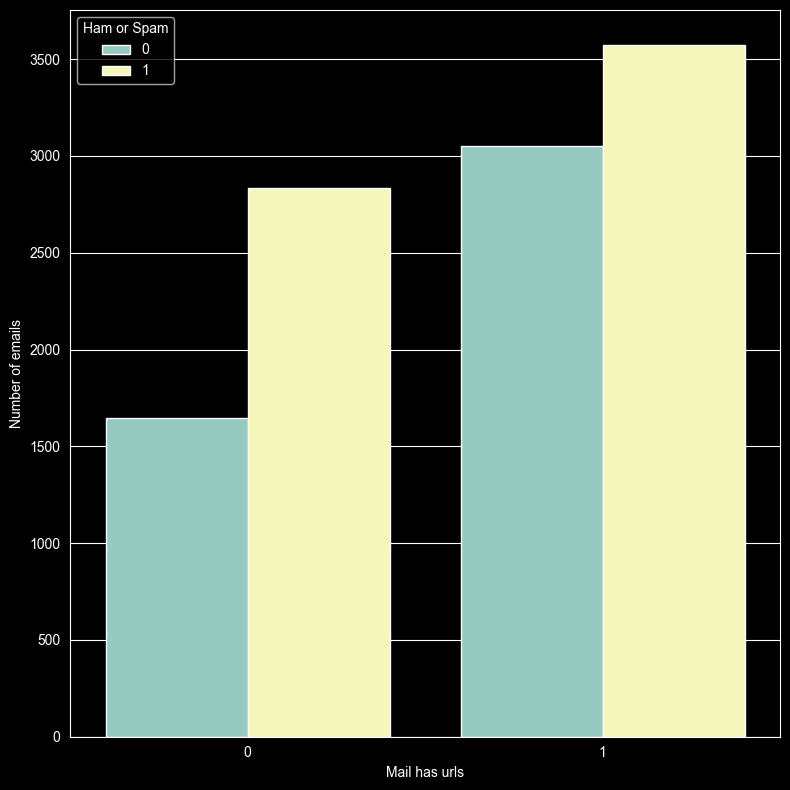

In [37]:
plt.figure(figsize=(8,8))
sb.countplot(data=data, x='urls',hue='label')
plt.xlabel('Mail has urls')
plt.ylabel('Number of emails')
plt.legend(title='Ham or Spam')
plt.tight_layout()
plt.show()

Iz sender promenljive su izvucena znacanja obelezja za analizu, tako da cu je sad odstraniti posto nema svrhu u daljem treniranju

In [38]:
data.drop(labels=['sender'],axis=1,inplace=True)

In [39]:
data.label.value_counts(normalize=True)

label
1    0.577283
0    0.422717
Name: proportion, dtype: float64

Sobzirom da ne postoji veliki disbalans u izlaznoj promenljivoj, neću koristiti SMOTE metodu balansiranja


Transformacija tekstualnih promenljvih koriscenjem spacy biblioteke


In [40]:
# Koristicu spacy medium model koji podrzava vektorsku reprezentaciju reci sa 300 dimenzija, mislim da je veci model suvisan
!python -m spacy download en_core_web_md
import spacy
nlp_md = spacy.load('en_core_web_md',disable=['parser', 'ner'])

     ---------------------------------------- 0.0/33.5 MB ? eta -:--:--
     ---- ----------------------------------- 3.7/33.5 MB 33.3 MB/s eta 0:00:01
     -------------- ------------------------ 12.6/33.5 MB 39.6 MB/s eta 0:00:01
     -------------------------- ------------ 22.8/33.5 MB 43.5 MB/s eta 0:00:01
     --------------------------------------  33.0/33.5 MB 45.1 MB/s eta 0:00:01
     ---------------------------------------- 33.5/33.5 MB 40.2 MB/s  0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_md')


Sledece sto je potrebno da uradim je ciscenje tekstualnih podataka od nepotrebih karaktera.


In [41]:
import re
def clean_text(text):
    if not isinstance(text,str):
        return ""

    try:
        # Zamena zapisa vezanih za starije Mime formate
        text = re.sub(r'^(content-type|x-mailer|x-priority|mime-version|content-transfer-encoding|return-path|delivered-to):.*$', '', text, flags=re.MULTILINE)

        # Zamena url-ova i mejlova sa uniformnim obelezjima
        text = re.sub(r'http\S+|www\.\S+', ' urladdr ', text)
        text = re.sub(r'\S+@\S+', ' emailaddr ', text)

        # Zamena re, fwd i [] mejlova zato što za to postoji obeležje
        text = re.sub(r"(re|fwd?):?\s*","",text,flags=re.IGNORECASE)
        text = re.sub(r"\[.*?\]","",text)

        # Zamena html tagova
        text = re.sub(r"<[^>]+>","",text)

        text = re.sub(r"[^a-zA-Z0-9'\s]"," ",text)
        return re.sub(r"\s+"," ",text).strip()

    except Exception as e:
        return f"Error {e} \n on text: {text}"

data['subject'] = data['subject'].apply(clean_text)
data['body'] = data['body'].apply(clean_text)

Sledece sto treba da se uradi je lematizacija tokena


In [42]:
def text_preprocessing(text):
    if not isinstance(text,str):
        return ""

    doc = nlp_md(text)
    return " ".join([t.lemma_.lower() for t in doc
                     if not (t.is_stop or t.is_punct or t.is_digit or t.like_url or t.lemma_.lower() in ["emailaddr","urladdr"])])

data['subject'] = data['subject'].apply(text_preprocessing)
data['body'] = data['body'].apply(text_preprocessing)

In [43]:
data[['subject','body']]

,subject,body
0,age loser,buck trouble cause small dimension soon lover ...
1,befriend jenna jameson,upgrade sex pleasus technique
2,cnn com daily,daily cnn com video story aug pm edt video mon...
3,svn commit r619753 spamassassin trunk lib mail...,object move list tld basically dead find lot b...
4,specialpricespharmmoinfo,welcomefastshippingcustomersupport
...,...,...
39136,finally new healthy life,find love stick gain heclick heurl qoqzcjyf9855v2
39138,want cancel account,cancel account want erase completely account s...
39139,contact information,message intend save save save best selling med...
39143,woman richter,lana year old woman seek seek man locate usa d...


Provera NA vrednosti nakon obrade promenljivih

In [44]:
data.isna().sum()

receiver               0
subject                0
body                   0
label                  0
urls                   0
is_internal            0
day_of_week           12
hour_of_day           12
is_reply               0
has_subject_header     0
is_forward             0
dtype: int64

Sobzirom da mali broj opservacija sadrži NA vrednosti (<10%), odlučio sam da ih odstranim iz dataset-a


In [45]:
empty_subjects_indices = data[data['subject'] == ""].index
data.drop(empty_subjects_indices, inplace=True)

empty_body_indices = data[data['body'] == ""].index
data.drop(empty_body_indices,inplace=True)

missing_days = data[data.isna()['day_of_week'] == True].index
data.drop(missing_days,inplace=True)

missing_hours = data[data.isna()['hour_of_day'] == True].index
data.drop(missing_hours,inplace=True)

data['hour_of_day'] = pd.to_numeric(data['hour_of_day'],errors='coerce')

Finalne ulazne promenljive predstavljaju kombinaciju obradjenih tekstualnih promenljivi i izdvojenih obeležja


Train test podela mejlova, gde 20% pripada test skupu

In [46]:
from sklearn.model_selection import train_test_split
feature_cols = ['day_of_week', 'hour_of_day', 'is_forward','has_subject_header','is_reply','is_internal']

y_encodings,y_levels = pd.factorize(data['label'])
X_train_raw, X_test_raw, y_train,y_test = train_test_split(
    data, data['label'],test_size=0.2,random_state=42,stratify=y_encodings
)

Sledeća metoda paralelno kreira vektore na osnovu prosleđene promenljive

In [47]:
import numpy as np
def get_vectors(column):
    vectors = [doc.vector for doc in nlp_md.pipe(column, batch_size=200)]
    return np.array(vectors)

Na osnovu train test podele, potrebno je uraditi vektorizaciju tekstualnih kolona i spojiti ih sa izvedenim obeležjima, primenom medium spacy modela ostvaruje se da svaki vektor ima po 300 dimenzija, tako da će izlazni dataframe imati 600 kolona za vektore naslova i tela mejla i 6 dodatnih kolona za ivedena obeležja

In [48]:
X_train_subject = get_vectors(X_train_raw['subject'])
X_train_body = get_vectors(X_train_raw['body'])

X_test_subject = get_vectors(X_test_raw['subject'])
X_test_body = get_vectors(X_test_raw['body'])

X_train_final = np.hstack((X_train_subject, X_train_body, X_train_raw[feature_cols].values))
X_test_final = np.hstack((X_test_subject, X_test_body, X_test_raw[feature_cols].values))

print(f"Finalna dimenzija trening matrice: {X_train_final.shape}")

Finalna dimenzija trening matrice: (8800, 606)


Kreiranje RandomForrest klasifikatora sa 150 stabala odlučivanja i maksimalnom dubinom 15-og nivoa. RandomForrest će nasumično uzeti podskup mejlova i za taj podskup izvršiti klasifikaciju. Svako od 150 stabala će onda predviđati da li je test mejl spam ili ne

In [49]:
from sklearn.ensemble import RandomForestClassifier
w2v_rf_model = RandomForestClassifier(n_estimators=150,max_depth=15, random_state=42,n_jobs=-1)

w2v_rf_model.fit(X_train_final,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",150
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",15
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

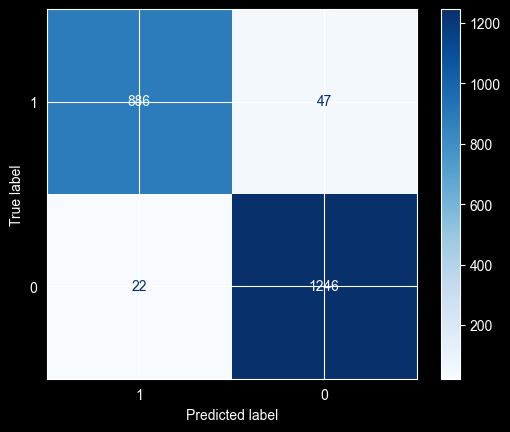

In [50]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay.from_estimator(
        w2v_rf_model,
        X_test_final,
        y_test,
        display_labels=y_levels,
        cmap='Blues')

886 mejlova je predviđeno kao spam od 933 spam mejla, dok je 22 predviđeno kao spam, a zapravo nisu

1246 mejlova je predviđeno kao ne spam od 1266 mejla, dok je 47 predviđeno kao ne spam a zapravo jesu

In [51]:
prediction_1 = w2v_rf_model.predict(X_test_final)
report_1 = classification_report(y_true = y_test, y_pred = prediction_1)
print(report_1)

              precision    recall  f1-score   support

           0       0.98      0.95      0.96       933
           1       0.96      0.98      0.97      1268

    accuracy                           0.97      2201
   macro avg       0.97      0.97      0.97      2201
weighted avg       0.97      0.97      0.97      2201



Preciznost govori da od svih mejlova, koje je model označio kao spam, 96% su zapravo spam, a od svih mejlova koje je model označio kao ne spam, 98% zapravo nisu spam

Odziv govori da od svih spam mejlova, model je uspeo da prepozna 98% spam mejlova, a od svih ne spam mejlova uspeo je da prepozna 95%

F1 skor je visok tako da se može zaključiti da je model izbalansiran

Testiraću optimalnost visine šume i broja stabala

In [52]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30, None]
}

grid_search = GridSearchCV(
    estimator=w2v_rf_model,
    param_grid=param_grid,
    cv=5,
    scoring='precision',
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train_final,y_train)

best_depth = grid_search.best_params_['max_depth']
best_n = grid_search.best_params_['n_estimators']

print("Optimalna visina: ", best_depth)
print("Optimalni broj stabala", best_n)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Optimalna visina:  10
Optimalni broj stabala 300


In [53]:
w2v_rf_model.set_params(n_estimators=best_n,max_depth=best_depth)
w2v_rf_model.fit(X_train_final,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

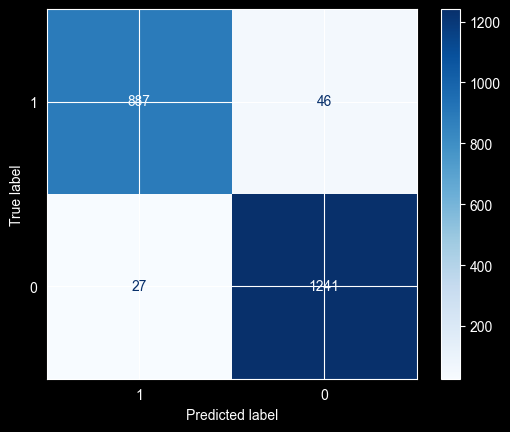

In [54]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay.from_estimator(
        w2v_rf_model,
        X_test_final,
        y_test,
        display_labels=y_levels,
        cmap='Blues')

887 mejlova je predviđeno kao spam od 933 spam mejlova, dok je 27 predviđeno kao spam a zapravo nisu

1241 mejlova je predviđeno kao ne spam od 1268 ne spam mejlova, dok je 36 predviđeno kao ne spam, a zapravo jesu

In [55]:
prediction_2 = w2v_rf_model.predict(X_test_final)
report_2 = classification_report(y_true = y_test, y_pred = prediction_2)
print(report_2)

              precision    recall  f1-score   support

           0       0.97      0.95      0.96       933
           1       0.96      0.98      0.97      1268

    accuracy                           0.97      2201
   macro avg       0.97      0.96      0.97      2201
weighted avg       0.97      0.97      0.97      2201



Primenom optimalnih hiperparametara došlo je do smanjenja preciznosti u predviđanju ne spam mejlova za 1%

Eksportovanje modela za zaključak

In [56]:
import joblib

joblib.dump(w2v_rf_model,'../models/w2v_rf_ceas.pkl')
joblib.dump(X_test_final,'../models/X_test_w2v_rf_ceas.pkl')
joblib.dump(y_test,'../models/y_test_w2v_rf_ceas.pkl')


['../models/y_test_w2v_rf_ceas.pkl']